In [1]:
%matplotlib inline

In [2]:
from src.utils.gantt_utils import (
    load_project_sheet,
    load_template_sheet,
    build_project_schedule_forward,
    build_project_schedule_backward,
    build_master_schedule,
    plot_gantt,
    plot_gantt_weekly,
    build_weekly_role_demand,
    plot_weekly_role_demand
)

In [3]:
file_path = "data/project_tasks.xlsx"

projects = load_project_sheet(file_path)
projects

,project_name,template_name,startline,buffer_days,deadline
0,Jembatan Medan,CES,2026-07-31,0,NaT
1,Jembatan Medan,SD,2026-07-31,0,NaT
2,Jembatan Medan,FT,2026-07-31,0,NaT
3,Jembatan Jakarta,CES,2026-07-31,0,NaT
4,Jembatan Jakarta,SD,2026-07-31,0,NaT
5,Jembatan Jakarta,FT,2026-07-31,0,NaT


In [4]:
ces = load_template_sheet(file_path, "CES")
ces

,task_id,dependencies,task_group,task_description,duration_days,role
0,1,,Section,Review section input,2,CES Engineer
1,2,1.0,Material,Define material properties,1,CES Engineer
2,3,2.0,Structure Geometry,Build structural geometry,3,CES Engineer
3,4,3.0,Boundary Condition,Define supports and links,2,CES Engineer
4,5,3.0,Tendon,Input tendon profile,2,CES Engineer
5,6,5.0,Bridge Loading,Define bridge loads,2,CES Engineer
6,7,6.0,Construction Sequence & Method,Build staged construction,4,CES Engineer
7,8,7.0,SSI Parameter,Input soil spring parameters,2,CES Engineer
8,9,4.0,Jacking force,Pressure jack calculation,14,CES Engineer


In [5]:
projects = load_project_sheet(file_path)

# build the project schedule forward from the startline:
medan_ces = build_project_schedule_forward(file_path, projects.iloc[0])

#if you want to build the schedule backward from the deadline, use:
# medan_ces = build_project_schedule_backward(file_path, projects.iloc[0])

medan_ces[["task_id", "task_group", "dependencies", "role", "start_date", "end_date"]]

,task_id,task_group,dependencies,role,start_date,end_date
0,1,Section,,CES Engineer,2026-07-31,2026-08-01
1,2,Material,1.0,CES Engineer,2026-08-02,2026-08-02
2,3,Structure Geometry,2.0,CES Engineer,2026-08-03,2026-08-05
3,4,Boundary Condition,3.0,CES Engineer,2026-08-06,2026-08-07
4,5,Tendon,3.0,CES Engineer,2026-08-06,2026-08-07
5,6,Bridge Loading,5.0,CES Engineer,2026-08-08,2026-08-09
6,9,Jacking force,4.0,CES Engineer,2026-08-08,2026-08-21
7,7,Construction Sequence & Method,6.0,CES Engineer,2026-08-10,2026-08-13
8,8,SSI Parameter,7.0,CES Engineer,2026-08-14,2026-08-15


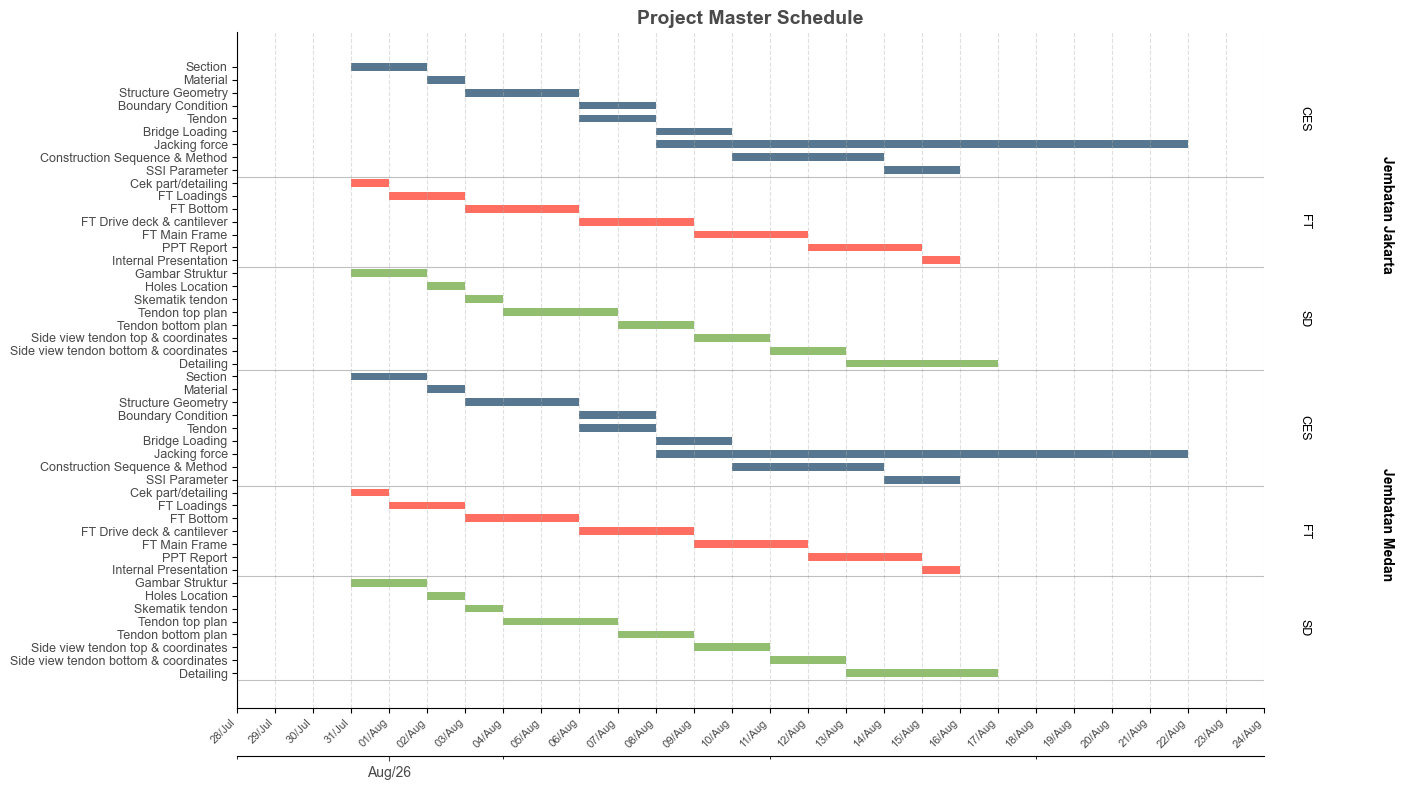

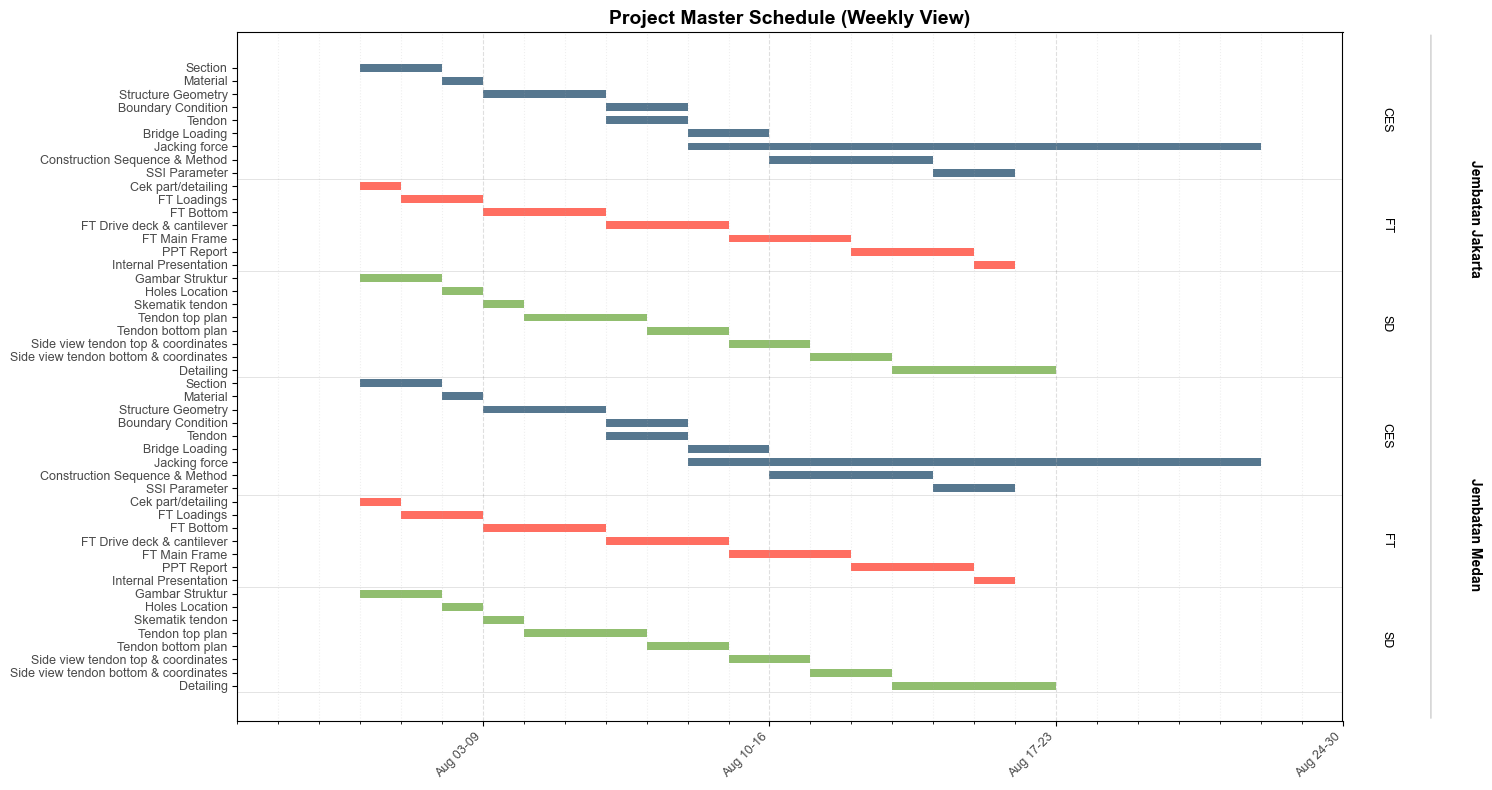

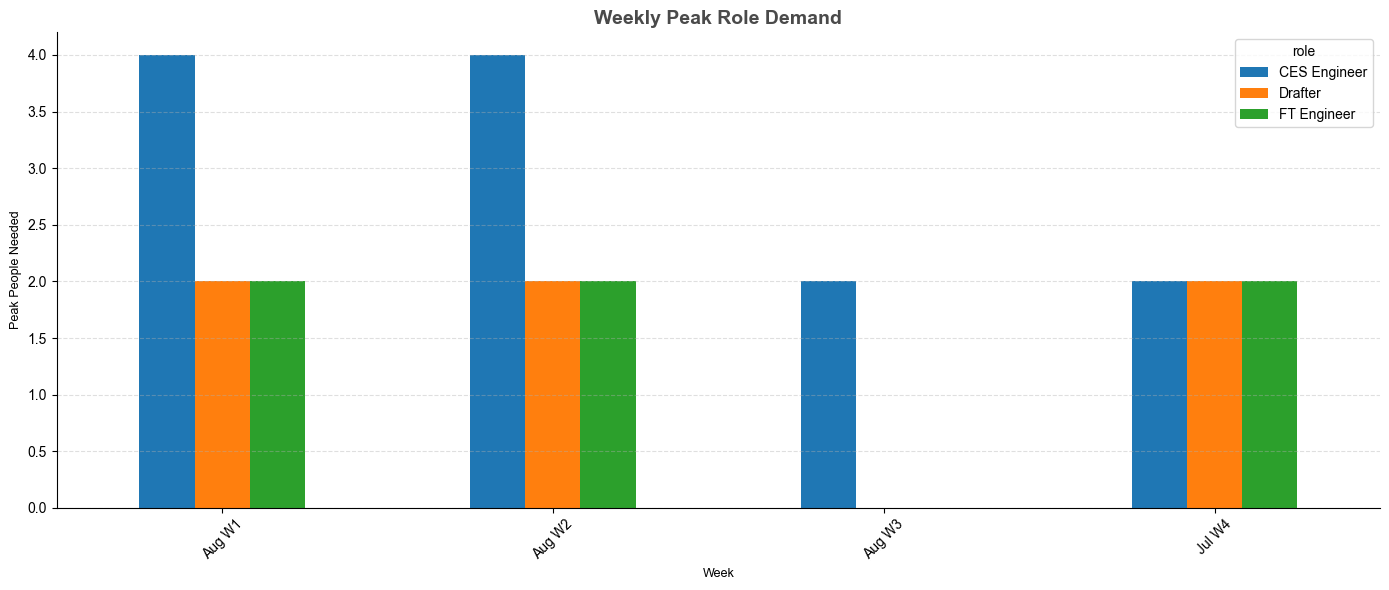

In [6]:
master_schedule = build_master_schedule(file_path)
plot_gantt(master_schedule)
plot_gantt_weekly(master_schedule)
plot_weekly_role_demand(master_schedule)

In [7]:

weekly_demand = build_weekly_role_demand(master_schedule)
weekly_demand

,week_start,role,people_needed,week_end,week_label
0,2026-07-27,CES Engineer,2,2026-08-02,Jul W4
1,2026-07-27,Drafter,2,2026-08-02,Jul W4
2,2026-07-27,FT Engineer,2,2026-08-02,Jul W4
3,2026-08-03,CES Engineer,4,2026-08-09,Aug W1
4,2026-08-03,Drafter,2,2026-08-09,Aug W1
5,2026-08-03,FT Engineer,2,2026-08-09,Aug W1
6,2026-08-10,CES Engineer,4,2026-08-16,Aug W2
7,2026-08-10,Drafter,2,2026-08-16,Aug W2
8,2026-08-10,FT Engineer,2,2026-08-16,Aug W2
9,2026-08-17,CES Engineer,2,2026-08-23,Aug W3
